ANOVA analysis - day-blocked CV

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, bartlett, anderson, normaltest

import pingouin as pg
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
# normality and homogeneity of variance tests for ANOVA assumptions
def check_anova_assumptions(df, group_col, metric_col, group_order=None):
    if group_order is None:
        group_order = df[group_col].unique()

    print(f"\n=== Normality test (D’Agostino and Pearson) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = normaltest(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Shapiro-Wilk) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = shapiro(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Anderson-Darling) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        result = anderson(data)
        stat = result.statistic
        crit_5 = result.critical_values[2]
        interpretation = "OK normal" if stat < crit_5 else "not normal"
        print(f"{group.ljust(25)}:\tA² = {stat:.4f},\t5% critical = {crit_5:.4f}\t→\t{interpretation}")

    print(f"\n=== Homogeneity of variance tests for {metric_col} ===")
    groups = [df[df[group_col] == group][metric_col] for group in group_order]

    stat_levene, p_levene = levene(*groups)
    result_levene = "OK equal variances" if p_levene > 0.05 else "unequal variances"
    print(f"Levene’s test  : p = {p_levene:.4f}\t→\t{result_levene}")

    stat_bartlett, p_bartlett = bartlett(*groups)
    result_bartlett = "OK equal variances" if p_bartlett > 0.05 else "unequal variances"
    print(f"Bartlett’s test: p = {p_bartlett:.4f}\t→\t{result_bartlett}")

    # Brown–Forsythe test (Levene with center='median')
    stat_bf, p_bf = levene(*groups, center='median')
    result_bf = "OK equal variances" if p_bf > 0.05 else "unequal variances"
    print(f"Brown–Forsythe : p = {p_bf:.4f}\t→\t{result_bf}")

In [3]:
def interpret_eta2(x: float) -> str:
    if x < 0.01:
        return "negligible"
    elif x < 0.06:
        return "small"
    elif x < 0.14:
        return "medium"
    else:
        return "large"

def interpret_d_like(x: float) -> str:
    ax = abs(x)
    if ax < 0.2:
        return "negligible"
    elif ax < 0.5:
        return "small"
    elif ax < 0.8:
        return "medium"
    else:
        return "large"

In [4]:
# ANOVA with eta squared, Games-Howell posthoc, and pairwise Hedges g effect sizes
def run_anova_full(df, group_col, metric_col, show_ci=True):
    # ===== Welch ANOVA =====
    print(f"\n=== Welch ANOVA for {metric_col} ===")
    welch = pg.welch_anova(dv=metric_col, between=group_col, data=df)
    print(welch.to_string(index=False))

    # Overall effect size (np2) interpretation
    if "np2" in welch.columns:
        np2 = float(welch.loc[0, "np2"])
        print(f"\nEffect size (partial η², np2) = {np2:.4f} → {interpret_eta2(np2)} effect")
    else:
        np2 = None
        print("\nEffect size: np2 not provided by Welch ANOVA output.")

    # ===== Games-Howell post-hoc =====
    print(f"\n=== Games-Howell post-hoc test for {metric_col} ===")
    gh = pg.pairwise_gameshowell(dv=metric_col, between=group_col, data=df).copy()
    print(gh.to_string(index=False))

    # ===== Pairwise effect sizes =====
    print(f"\n=== Pairwise effect sizes for {metric_col} (Hedges' g) ===")
    group_labels = list(pd.unique(df[group_col]))
    label_width = max(len(str(g)) for g in group_labels) + 2

    for g1, g2 in combinations(group_labels, 2):
        x = df.loc[df[group_col] == g1, metric_col].to_numpy()
        y = df.loc[df[group_col] == g2, metric_col].to_numpy()

        g = float(pg.compute_effsize(x, y, eftype="hedges"))
        effect = interpret_d_like(g)

        line = (
            f"{str(g1).ljust(label_width)} vs {str(g2).ljust(label_width)}:"
            f" g = {g:.4f} → {effect} effect"
        )

        if show_ci:
            ci = pg.compute_bootci(
                x, y,
                func=lambda a, b: pg.compute_effsize(a, b, eftype="hedges"),
                confidence=0.95,
                method="percentile",
            )
            line += f"   95% CI [{ci[0]:.4f}, {ci[1]:.4f}]"

        print(line)

## Time independent - CO2

In [5]:
model = "time independent CO2"
A_low = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_low_state_timeindep_co2.csv")
A_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_mid_state_timeindep_co2.csv")
A_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_top_state_timeindep_co2.csv")
B_low = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_low_state_timeindep_co2.csv")
B_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_mid_state_timeindep_co2.csv")
B_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_top_state_timeindep_co2.csv")
C_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_C_mid_state_timeindep_co2.csv")
C_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_C_top_state_timeindep_co2.csv")


In [6]:
A_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
repeat,100.0,9.500000,5.795331,0.000000,4.750000,9.500000,14.250000,19.000000
fold,100.0,2.000000,1.421338,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
accuracy,100.0,0.863758,0.035371,0.766871,0.843678,0.866844,0.887326,0.953125
f1_weighted,100.0,0.860738,0.036890,0.755143,0.839494,0.863822,0.885194,0.952099
balanced_acc,100.0,0.825378,0.031000,0.754373,0.805526,0.822541,0.845652,0.911719
auc,100.0,0.901010,0.031762,0.805678,0.888419,0.905969,0.923808,0.959662
model_weights.random_forest,100.0,1.282244,1.202321,-1.934520,0.540088,1.206512,2.057481,3.969327
model_weights.bagging_svc,100.0,0.451455,0.556310,-0.679466,0.053688,0.429460,0.812704,1.974195


In [7]:
A_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
repeat,100.0,9.500000,5.795331,0.000000,4.750000,9.500000,14.250000,19.000000
fold,100.0,2.000000,1.421338,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
accuracy,100.0,0.871377,0.041332,0.765337,0.839236,0.872838,0.899822,0.960669
f1_weighted,100.0,0.867386,0.043826,0.753295,0.834075,0.869656,0.897306,0.958721
balanced_acc,100.0,0.831066,0.042149,0.696237,0.807212,0.836099,0.859996,0.914054
auc,100.0,0.899662,0.042633,0.699255,0.883118,0.906698,0.927377,0.979794
model_weights.random_forest,100.0,0.173876,1.331694,-2.656602,-0.883921,0.134231,1.017132,3.492730
model_weights.bagging_svc,100.0,0.403145,0.848709,-1.497335,-0.228083,0.318691,1.006475,2.492995


In [8]:
A_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
repeat,100.0,9.500000,5.795331,0.000000,4.750000,9.500000,14.250000,19.000000
fold,100.0,2.000000,1.421338,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
accuracy,100.0,0.871515,0.041216,0.761503,0.843259,0.871126,0.902257,0.959685
f1_weighted,100.0,0.869167,0.042785,0.752082,0.840431,0.869322,0.901804,0.956720
balanced_acc,100.0,0.840059,0.038663,0.751991,0.812469,0.840482,0.864870,0.915556
auc,100.0,0.907003,0.034334,0.811113,0.883244,0.910660,0.935968,0.964915
model_weights.random_forest,100.0,0.796352,0.884719,-1.411974,0.276989,0.804835,1.407956,2.817019
model_weights.bagging_svc,100.0,-0.083499,1.292120,-2.454963,-0.964322,-0.440910,0.618496,3.216239


In [9]:
B_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
repeat,100.0,9.500000,5.795331,0.000000,4.750000,9.500000,14.250000,19.000000
fold,100.0,2.000000,1.421338,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
accuracy,100.0,0.839316,0.043117,0.733961,0.806879,0.839488,0.874132,0.933078
f1_weighted,100.0,0.834658,0.045770,0.722108,0.799008,0.837422,0.872825,0.931628
balanced_acc,100.0,0.794819,0.035984,0.709067,0.767596,0.793187,0.821920,0.892640
auc,100.0,0.871937,0.039930,0.772392,0.845419,0.874742,0.902076,0.959392
model_weights.random_forest,100.0,-0.064398,1.249527,-2.715277,-0.843681,-0.025315,0.815305,2.473525
model_weights.bagging_svc,100.0,0.372863,0.521762,-0.939374,0.017179,0.374213,0.716231,1.820168


In [10]:
B_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
repeat,100.0,9.500000,5.795331,0.000000,4.750000,9.500000,14.250000,19.000000
fold,100.0,2.000000,1.421338,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
accuracy,100.0,0.854088,0.043551,0.740798,0.826172,0.855706,0.885942,0.954769
f1_weighted,100.0,0.851477,0.044938,0.727718,0.820262,0.851208,0.884230,0.953330
balanced_acc,100.0,0.819339,0.037365,0.729986,0.793778,0.816456,0.839076,0.902125
auc,100.0,0.886739,0.038591,0.798759,0.866693,0.885372,0.912385,0.979583
model_weights.random_forest,100.0,0.362281,1.270270,-2.649062,-0.547413,0.241684,1.291311,3.158527
model_weights.bagging_svc,100.0,0.831110,0.675056,-0.767335,0.283824,0.842498,1.346795,2.225998


In [11]:
B_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
repeat,100.0,9.500000,5.795331,0.000000,4.750000,9.500000,14.250000,19.000000
fold,100.0,2.000000,1.421338,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
accuracy,100.0,0.882399,0.039984,0.776074,0.852170,0.882901,0.913860,0.975418
f1_weighted,100.0,0.880317,0.041191,0.768704,0.848282,0.882234,0.910834,0.973093
balanced_acc,100.0,0.852368,0.036018,0.762719,0.825283,0.856941,0.876218,0.927323
auc,100.0,0.906323,0.038114,0.817462,0.878030,0.914453,0.933885,0.970281
model_weights.random_forest,100.0,-0.238878,0.995504,-2.423532,-0.909241,-0.259115,0.597123,2.000501
model_weights.bagging_svc,100.0,0.044813,0.917844,-1.564664,-0.625738,-0.144133,0.717342,2.662530


In [12]:
C_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
repeat,100.0,9.500000,5.795331,0.000000,4.750000,9.500000,14.250000,19.000000
fold,100.0,2.000000,1.421338,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
accuracy,100.0,0.873719,0.038935,0.776074,0.842686,0.876399,0.901445,0.947886
f1_weighted,100.0,0.870832,0.040855,0.766703,0.839433,0.874726,0.900048,0.949161
balanced_acc,100.0,0.838896,0.036580,0.744416,0.812025,0.839129,0.861916,0.926103
auc,100.0,0.899455,0.039836,0.781471,0.871799,0.903769,0.928831,0.973652
model_weights.random_forest,100.0,0.635780,1.093364,-1.914262,-0.281606,0.863747,1.375653,3.070946
model_weights.bagging_svc,100.0,0.181353,0.477705,-1.125849,-0.110464,0.190670,0.522750,1.186593


In [13]:
C_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
repeat,100.0,9.500000,5.795331,0.000000,4.750000,9.500000,14.250000,19.000000
fold,100.0,2.000000,1.421338,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,100.0,49.500000,29.011492,0.000000,24.750000,49.500000,74.250000,99.000000
accuracy,100.0,0.867766,0.044813,0.773006,0.837053,0.864805,0.907796,0.979351
f1_weighted,100.0,0.864009,0.046820,0.761379,0.831048,0.862639,0.904475,0.978036
balanced_acc,100.0,0.829354,0.038579,0.717433,0.802068,0.832563,0.860192,0.912395
auc,100.0,0.895581,0.042445,0.692548,0.871946,0.899265,0.921520,0.964720
model_weights.random_forest,100.0,0.246657,1.197113,-3.147852,-0.650437,0.174660,1.118617,3.424458
model_weights.bagging_svc,100.0,-0.134867,0.788505,-1.980994,-0.618695,-0.241693,0.277105,2.025877


In [14]:
A_low['case'] = 'A_low'
A_mid['case'] = 'A_mid'
A_top['case'] = 'A_top'
B_low['case'] = 'B_low'
B_mid['case'] = 'B_mid'
B_top['case'] = 'B_top'
C_mid['case'] = 'C_mid'
C_top['case'] = 'C_top'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        A_low[metrics],
        A_mid[metrics],
        A_top[metrics],
        B_low[metrics],
        B_mid[metrics],
        B_top[metrics],
        C_mid[metrics],
        C_top[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          800 non-null    object 
 1   accuracy      800 non-null    float64
 2   f1_weighted   800 non-null    float64
 3   balanced_acc  800 non-null    float64
 4   auc           800 non-null    float64
dtypes: float64(4), object(1)
memory usage: 31.4+ KB


In [15]:
case_order = ['A_low', 'A_mid', 'A_top', 'B_low', 'B_mid', 'B_top', 'C_mid', 'C_top']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,A_low,A_low,A_low,A_low,A_low
accuracy,0.859028,0.868199,0.855932,0.902778,0.858268
f1_weighted,0.853616,0.866993,0.8457,0.902323,0.853935
balanced_acc,0.818976,0.841673,0.780382,0.886579,0.814986
auc,0.923793,0.883179,0.899474,0.949881,0.911611
x,0,0,0,0,0
x_jitter,0.083713,0.012917,0.044889,-0.060131,-0.090431


### plot

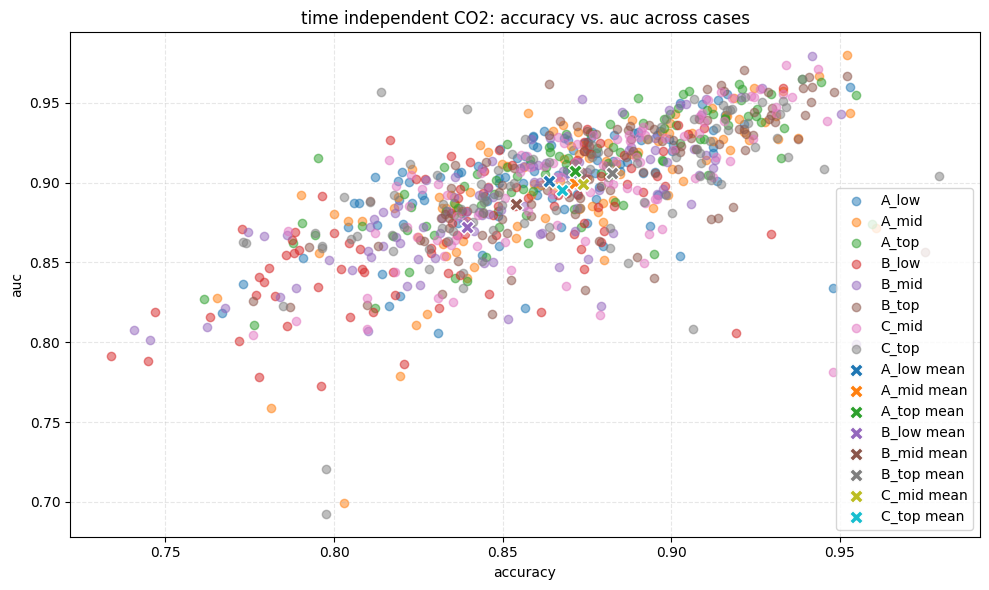

In [16]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

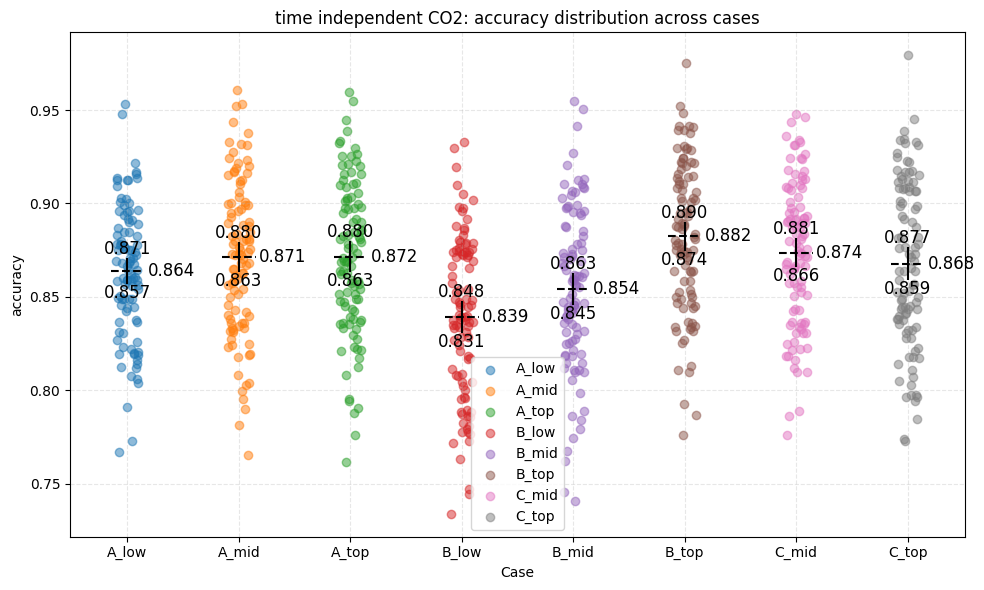

In [17]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

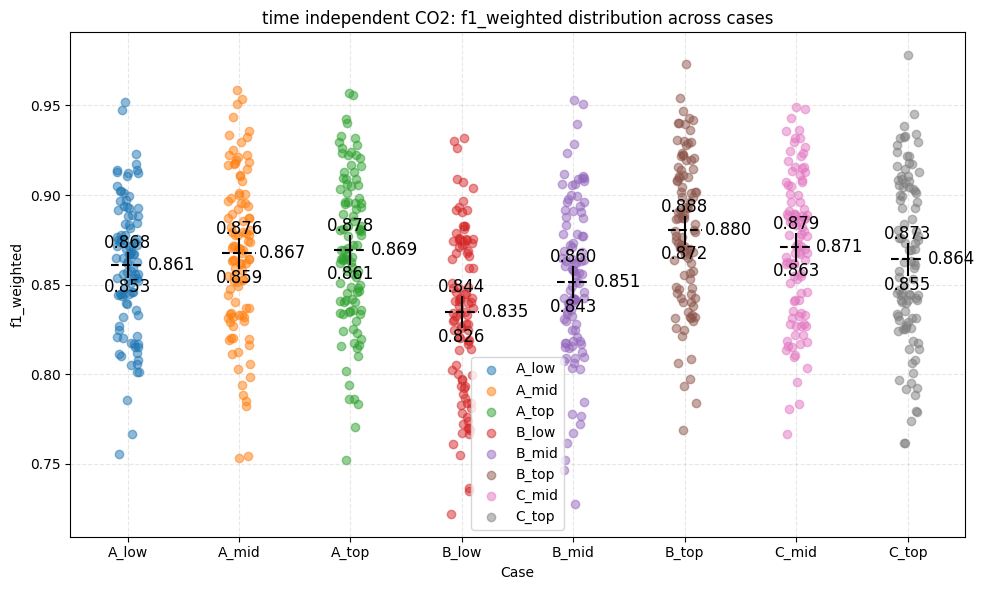

In [18]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

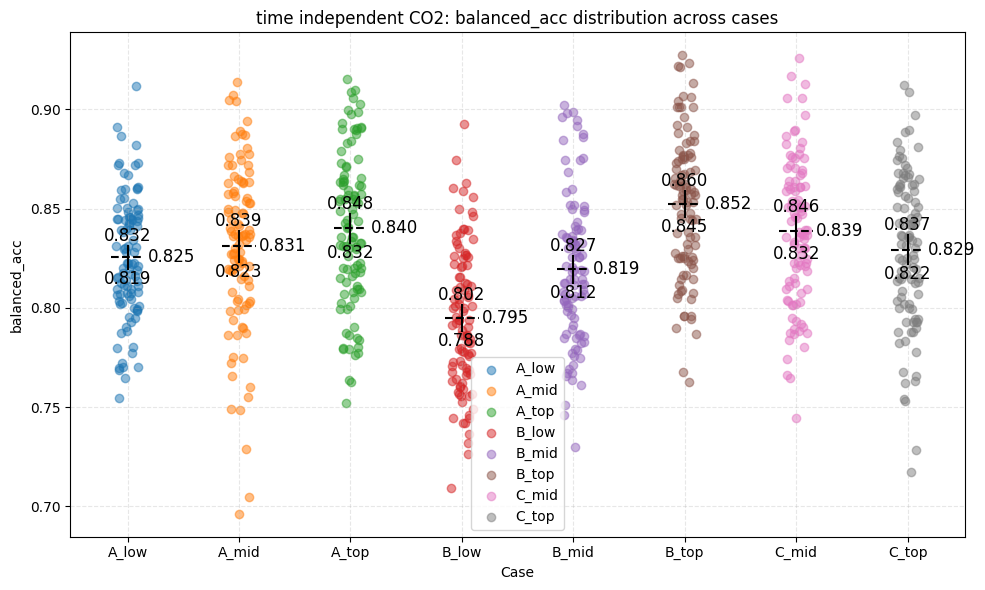

In [19]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

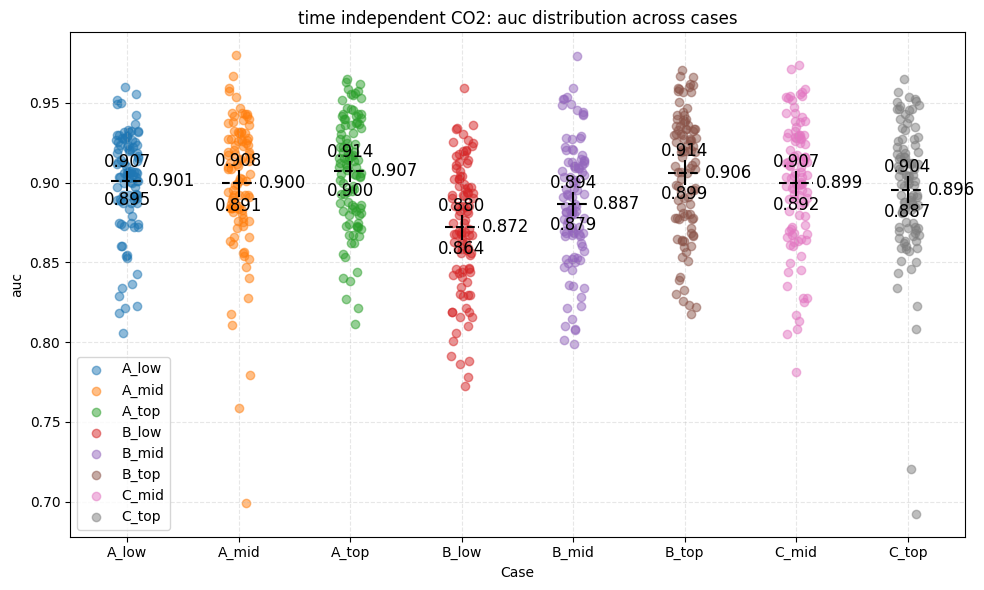

In [20]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for accuracy ===
A_low                    :	p = 0.5986	→	OK normal
A_mid                    :	p = 0.5834	→	OK normal
A_top                    :	p = 0.5326	→	OK normal
B_low                    :	p = 0.3187	→	OK normal
B_mid                    :	p = 0.7206	→	OK normal
B_top                    :	p = 0.4375	→	OK normal
C_mid                    :	p = 0.2173	→	OK normal
C_top                    :	p = 0.0554	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
A_low                    :	p = 0.6248	→	OK normal
A_mid                    :	p = 0.8730	→	OK normal
A_top                    :	p = 0.7482	→	OK normal
B_low                    :	p = 0.2447	→	OK normal
B_mid                    :	p = 0.7651	→	OK normal
B_top                    :	p = 0.5120	→	OK normal
C_mid                    :	p = 0.2279	→	OK normal
C_top                    :	p = 0.0907	→	OK normal

=== Normality test (Anderson-Darling) for accuracy ===
A_low    

In [22]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
A_low                    :	p = 0.5557	→	OK normal
A_mid                    :	p = 0.6159	→	OK normal
A_top                    :	p = 0.5019	→	OK normal
B_low                    :	p = 0.3873	→	OK normal
B_mid                    :	p = 0.6236	→	OK normal
B_top                    :	p = 0.4063	→	OK normal
C_mid                    :	p = 0.2413	→	OK normal
C_top                    :	p = 0.1582	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
A_low                    :	p = 0.6734	→	OK normal
A_mid                    :	p = 0.6848	→	OK normal
A_top                    :	p = 0.6255	→	OK normal
B_low                    :	p = 0.2908	→	OK normal
B_mid                    :	p = 0.6300	→	OK normal
B_top                    :	p = 0.5258	→	OK normal
C_mid                    :	p = 0.2463	→	OK normal
C_top                    :	p = 0.1714	→	OK normal

=== Normality test (Anderson-Darling) for f1_weighted ===


In [23]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
A_low                    :	p = 0.9164	→	OK normal
A_mid                    :	p = 0.0060	→	not normal
A_top                    :	p = 0.1061	→	OK normal
B_low                    :	p = 0.5331	→	OK normal
B_mid                    :	p = 0.4815	→	OK normal
B_top                    :	p = 0.5705	→	OK normal
C_mid                    :	p = 0.8353	→	OK normal
C_top                    :	p = 0.2966	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
A_low                    :	p = 0.8056	→	OK normal
A_mid                    :	p = 0.0218	→	not normal
A_top                    :	p = 0.2188	→	OK normal
B_low                    :	p = 0.8505	→	OK normal
B_mid                    :	p = 0.1666	→	OK normal
B_top                    :	p = 0.5845	→	OK normal
C_mid                    :	p = 0.9340	→	OK normal
C_top                    :	p = 0.4259	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc

In [24]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for auc ===
A_low                    :	p = 0.0009	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.1276	→	OK normal
B_low                    :	p = 0.1991	→	OK normal
B_mid                    :	p = 0.7546	→	OK normal
B_top                    :	p = 0.0502	→	OK normal
C_mid                    :	p = 0.0380	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
A_low                    :	p = 0.0002	→	not normal
A_mid                    :	p = 0.0000	→	not normal
A_top                    :	p = 0.0359	→	not normal
B_low                    :	p = 0.1355	→	OK normal
B_mid                    :	p = 0.5088	→	OK normal
B_top                    :	p = 0.0042	→	not normal
C_mid                    :	p = 0.0167	→	not normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
A_low         

### ANOVA

In [25]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent CO2

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2        F        p-unc      np2
  case      7 339.276624 9.964368 2.509939e-11 0.085182

Effect size (partial η², np2) = 0.0852 → medium effect

=== Games-Howell post-hoc test for accuracy ===
    A     B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
A_low A_mid 0.863758 0.871377 -0.007619 0.005440 -1.400547 193.384018 8.561368e-01 -0.197316
A_low A_top 0.863758 0.871515 -0.007756 0.005431 -1.428104 193.543433 8.432145e-01 -0.201198
A_low B_low 0.863758 0.839316  0.024443 0.005577  4.382846 190.713366 5.049945e-04  0.617477
A_low B_mid 0.863758 0.854088  0.009670 0.005611  1.723593 190.008786 6.718878e-01  0.242828
A_low B_top 0.863758 0.882399 -0.018640 0.005338 -3.491734 195.097368 1.354210e-02 -0.491933
A_low C_mid 0.863758 0.873719 -0.009960 0.005260 -1.893516 196.202854 5.570296e-01 -0.266768
A_low C_top 0.863758 0.867766 -0.004008 0.005709 -0.701983 187.863232 9.96859

In [26]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent CO2

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2        F        p-unc      np2
  case      7 339.269621 9.851119 3.409299e-11 0.084848

Effect size (partial η², np2) = 0.0848 → medium effect

=== Games-Howell post-hoc test for f1_weighted ===
    A     B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
A_low A_mid 0.860738 0.867386 -0.006648 0.005729 -1.160505 192.399692 9.419501e-01 -0.163498
A_low A_top 0.860738 0.869167 -0.008429 0.005649 -1.492120 193.802015 8.108969e-01 -0.210217
A_low B_low 0.860738 0.834658  0.026080 0.005879  4.436438 189.452724 4.065757e-04  0.625027
A_low B_mid 0.860738 0.851477  0.009261 0.005814  1.592862 190.760206 7.541042e-01  0.224410
A_low B_top 0.860738 0.880317 -0.019579 0.005530 -3.540846 195.640375 1.150605e-02 -0.498852
A_low C_mid 0.860738 0.870832 -0.010094 0.005505 -1.833834 195.971634 5.978547e-01 -0.258360
A_low C_top 0.860738 0.864009 -0.003271 0.005961 -0.548778 187.725775 9

In [27]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent CO2

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      7 339.219163 22.023395 1.652394e-24 0.157557

Effect size (partial η², np2) = 0.1576 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
    A     B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
A_low A_mid 0.825378 0.831066 -0.005688 0.005232  -1.087099 181.858668 9.588150e-01 -0.153156
A_low A_top 0.825378 0.840059 -0.014681 0.004956  -2.962588 189.066422 6.632815e-02 -0.417384
A_low B_low 0.825378 0.794819  0.030559 0.004750   6.434114 193.755736 2.650866e-08  0.906470
A_low B_mid 0.825378 0.819339  0.006039 0.004855   1.243882 191.473191 9.175942e-01  0.175244
A_low B_top 0.825378 0.852368 -0.026989 0.004752  -5.679429 193.703506 1.353296e-06 -0.800146
A_low C_mid 0.825378 0.838896 -0.013518 0.004795  -2.819284 192.811650 9.625824e-02 -0.397195
A_low C_top 0.825378 0.829354 -0.003976 0.004949  -0.803423 1

In [28]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent CO2

=== Welch ANOVA for auc ===
Source  ddof1      ddof2       F        p-unc      np2
  case      7 339.140044 8.94794 3.968344e-10 0.073943

Effect size (partial η², np2) = 0.0739 → medium effect

=== Games-Howell post-hoc test for auc ===
    A     B  mean(A)  mean(B)      diff       se         T         df         pval    hedges
A_low A_mid 0.901010 0.899662  0.001347 0.005316  0.253449 183.016612 9.999965e-01  0.035707
A_low A_top 0.901010 0.907003 -0.005993 0.004677 -1.281292 196.811722 9.048298e-01 -0.180515
A_low B_low 0.901010 0.871937  0.029073 0.005102  5.698156 188.464476 1.272852e-06  0.802785
A_low B_mid 0.901010 0.886739  0.014271 0.004998  2.855291 190.938412 8.788886e-02  0.402268
A_low B_top 0.901010 0.906323 -0.005314 0.004961 -1.070979 191.766033 9.620430e-01 -0.150885
A_low C_mid 0.901010 0.899455  0.001555 0.005095  0.305250 188.644586 9.999876e-01  0.043005
A_low C_top 0.901010 0.895581  0.005428 0.005301  1.023961 183.407380 9.702875e-01  0.144